## 📊 CAPM and Fama-French Analysis

This project analyzes stock excess returns using:
- CAPM (Capital Asset Pricing Model)
- Fama-French 3-Factor Model

Data: Monthly (1980–2024)
Stock: Procter & Gamble (PG)

In [1]:
!pip install pandas_datareader
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from IPython.display import display 
import yfinance as yf
import warnings

##  Data Collection

We download:
- Stock prices using Yahoo Finance
- Fama-French factors (Mkt-RF, SMB, HML, RF)

In [2]:
ticker_symbol = "PG"
start_date = "1980-01-01"
end_date   = "2024-12-31"


data = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False, auto_adjust=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

if 'Adj Close' in data.columns:
    prices = data['Adj Close'].dropna()
else:
    prices = data['Close'].dropna()
    
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Preparation

- Compute monthly returns
- Merge with Fama-French factors
- Calculate excess returns

In [3]:
# Compute monthly returns
rt = prices.pct_change().dropna()
rt_m = rt.resample('ME').mean()

In [4]:
# === 1. Download Fama-French Factors and Prepare Data ==================

# Download Fama-French factors (Mkt-RF, SMB, HML) and Risk-Free Rate (RF)
# [0] selects the monthly factors table.
ff_data = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="1980-01-01")[0]
ff_data.index = ff_data.index.to_timestamp() # Convert PeriodIndex to Timestamp Index

# Filter factors to match the asset's period (or your desired period)
ff_data = ff_data.loc[rt_m.index[0]:rt_m.index[-1]] 

# --- Prepare Asset Returns ---
# Multiply by 100 to work in percentages, which is standard for Fama-French data.
asset_returns_pct = rt_m.copy() * 100 
# Ensure asset index is proper Timestamp for alignment
asset_returns_pct.index = asset_returns_pct.index.to_period('M').to_timestamp() 

# Calculate Excess Returns (Asset Return - Risk-Free Rate)
# Note: Fama-French factors (Mkt-RF, SMB, HML) are already in percentage points.
# We use the RF from the Fama-French data.
data_ff = pd.concat([asset_returns_pct, ff_data[["Mkt-RF", "SMB", "HML", "RF"]]], axis=1, join="inner")
data_ff.columns = ["Asset_Excess", "Mkt_RF", "SMB", "HML", "RF"]

# RF is the risk-free rate in percentage, Asset_Excess is the asset return in percentage.
data_ff["Asset_Excess"] = data_ff["Asset_Excess"] - data_ff["RF"] 

print(f"Data aligned: {data_ff.shape[0]} monthly observations (1980–2024 period)")


Data aligned: 539 monthly observations (1980–2024 period)


##  CAPM Model

In [5]:

# ======================================================================
# MODEL 1: CAPM (Market Model)
# ======================================================================

# Dependent Variable (y): Asset Excess Returns
y = data_ff["Asset_Excess"]

# Explanatory Variables (X): Mkt-RF, plus a constant (alpha)
X_capm = sm.add_constant(data_ff["Mkt_RF"])

# Estimation by OLS
capm_model = sm.OLS(y, X_capm).fit()

# Summary of Regression Coefficients (Requirement a)
print("\n" + "="*50)
print("MODEL 1: CAPITAL ASSET PRICING MODEL (CAPM) – SUMMARY OUTPUT")
print("="*50)
print(capm_model.summary())




MODEL 1: CAPITAL ASSET PRICING MODEL (CAPM) – SUMMARY OUTPUT
                            OLS Regression Results                            
Dep. Variable:           Asset_Excess   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     57.39
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.58e-13
Time:                        09:25:07   Log-Likelihood:                -204.63
No. Observations:                 539   AIC:                             413.3
Df Residuals:                     537   BIC:                             421.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

## CAPM Visualization

The scatter plot shows a positive relationship between market and asset returns.

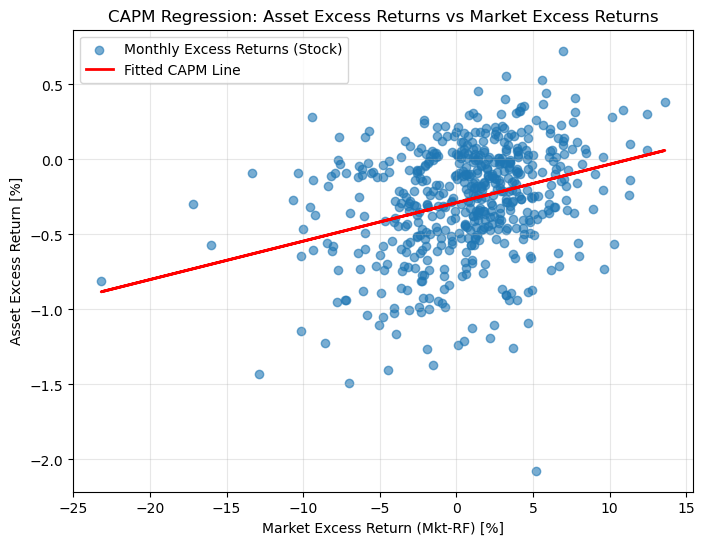

In [6]:
# Fitted Regression Line Plot (Requirement b)
plt.figure(figsize=(8, 6))
plt.scatter(data_ff["Mkt_RF"], y, alpha=0.6, label="Monthly Excess Returns (Stock)")
plt.plot(data_ff["Mkt_RF"], capm_model.predict(X_capm), color="red", lw=2, label="Fitted CAPM Line")
plt.xlabel("Market Excess Return (Mkt-RF) [%]")
plt.ylabel("Asset Excess Return [%]")
plt.title("CAPM Regression: Asset Excess Returns vs Market Excess Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('CAPM.png', format='png', bbox_inches='tight')
plt.show()
with open("CAPM_summary.html", "w") as f:
    f.write(capm_model.summary().as_html())


## FAMA-FRENCH model

In [7]:
# ======================================================================
# MODEL 2: Fama-French 3-Factor Model
# ======================================================================

# Explanatory Variables (X): Mkt-RF, SMB, HML, plus a constant (alpha)
X_ff3 = sm.add_constant(data_ff[["Mkt_RF", "SMB", "HML"]])

# Estimation OLS
ff3_model = sm.OLS(y, X_ff3).fit()

# Summary of Regression Coefficients (Requirement a)
print("\n" + "="*60)
print("MODEL 2: FAMA-FRENCH 3-FACTOR MODEL – SUMMARY OUTPUT")
print("="*60)
print(ff3_model.summary())
with open("FFF_summary.html", "w") as f:
    f.write(capm_model.summary().as_html())


MODEL 2: FAMA-FRENCH 3-FACTOR MODEL – SUMMARY OUTPUT
                            OLS Regression Results                            
Dep. Variable:           Asset_Excess   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     23.14
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.25e-14
Time:                        09:25:18   Log-Likelihood:                -199.11
No. Observations:                 539   AIC:                             406.2
Df Residuals:                     535   BIC:                             423.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

## Interpretation

### 1. Significance and Magnitude of Coefficients

In the CAPM model, the market beta is positive and highly statistically significant, indicating that the stock's excess returns are strongly related to market movements. The magnitude of beta (≈ 0.48) suggests that the stock is less volatile than the market.

In the Fama-French model, the market factor remains highly significant with a slightly higher beta (≈ 0.54). The SMB coefficient is negative and statistically significant, indicating that the stock behaves more like a large-cap stock. The HML coefficient is not statistically significant, suggesting that the value factor does not explain the stock’s returns.


### 2. Goodness of Fit

The CAPM model has an R² of approximately 0.15, meaning it explains about 15% of the variation in excess returns.

The Fama-French model improves the R² to approximately 0.19, indicating better explanatory power. This suggests that additional factors beyond market risk help explain asset returns.


### 3. Significance of Alpha

In both models, the alpha is not statistically significant. This implies that there is no strong evidence of abnormal returns once risk factors are taken into account.

This result is consistent with the Efficient Market Hypothesis and supports the CAPM prediction that alpha should be zero in equilibrium.


### 4. Economic Interpretation

The results suggest that:

- Market risk is the primary driver of returns (CAPM)
- Additional factors such as size (SMB) also play a role
- The lack of significant alpha supports market efficiency

These findings are consistent with multi-factor asset pricing theories such as the Arbitrage Pricing Theory (APT), which argue that multiple sources of risk affect expected returns.


### 5. Conclusion

Overall, the Fama-French model provides a better fit than the CAPM, but both models leave a large portion of return variation unexplained. This highlights the limitations of linear factor models in capturing all determinants of asset returns.

## Model Comparison

- Fama-French improves explanatory power
- Additional factors help explain returns
- Supports multi-factor models (APT)